#### Airbnb Demand Proxy Modeling in Dublin

This notebook analyzes Airbnb guest count patterns in Dublin using listing, search, and guest-contact data. Since the dataset does not contain a clean confirmed booking or nightly transaction price variable, guest count is sued as a proxy for market demand.

#### Dataset Overview

##### The analysis combines Airbnb listing, search, and contact-related data, including neighbourhood, room type, guest count, and booking-interaction variables.

#### Objective

##### The objective is to test whether listing, neighbourhood, and trip-related features can help explain variation in guest count. The project benchmarks Linear Regression and XGBoost against a navie mean baseline to evaluate whether machine learning models provide additional predictive value over a simple average prediction.

#### Scope and Limitation

##### This project should be interpreted as demand proxy modeling rather than true booking-demand forecasting or rental price prediction. The dataset does not include confirmed bookings, occupancy rates, revenue, or a clean nightly listing price field. Therefore, the model mainly to identify predictive signals and demand patterns, not to produce highly accurate business forecasts.

In [200]:
# Import libraries

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [201]:
contacts = pd.read_excel('contacts.xlsx')
searches = pd.read_excel('searches.xlsx')
result = contacts.merge(searches, left_on='id_guest', right_on='id_user', how='left')

#### Data Loading and Data Quality Checks

In [202]:
print(result.shape)
print(result.size)
print(result.info())

(28536, 24)
684864
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28536 entries, 0 to 28535
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_guest              28536 non-null  object        
 1   id_host               28536 non-null  object        
 2   id_listing            28536 non-null  object        
 3   ts_contact_at         28536 non-null  datetime64[ns]
 4   ts_reply_at           26275 non-null  datetime64[ns]
 5   ts_accepted_at        12257 non-null  datetime64[ns]
 6   ts_booking_at         6756 non-null   datetime64[ns]
 7   ds_checkin_x          28536 non-null  datetime64[ns]
 8   ds_checkout_x         28536 non-null  datetime64[ns]
 9   n_guests              28536 non-null  int64         
 10  n_messages            28536 non-null  int64         
 11  ds                    28536 non-null  datetime64[ns]
 12  id_user               28536 non-null  object        
 1

#### Missing Values

The variables filter_price_min and filter_price_max contain substantial missingness, so they require careful handling before being used in analysis or modeling.

In [203]:
missing = result.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

filter_neighborhoods    27014
ts_booking_at           21780
ts_accepted_at          16279
filter_room_types       14765
filter_price_max        14423
filter_price_min        14423
ds_checkout_y            6014
n_nights                 6014
ds_checkin_y             6014
ts_reply_at              2261
dtype: int64

#### Duplicate Records

Duplicate rows are removed only when the same guest, host, listing, check-in date, and check-out date appear more than once. This preserves legitimate repeat activity while removing exact duplicates.

In [204]:
result['ds_checkin_x'] = pd.to_datetime(result['ds_checkin_x'], errors='coerce')
result['ds_checkout_x'] = pd.to_datetime(result['ds_checkout_x'], errors='coerce')
result = result.drop_duplicates(subset=['id_guest', 'id_host', 'id_listing', 'ds_checkin_x', 'ds_checkout_x'])

Missing values in filter_price_min are imputed with 0 because this appears to represent the default lower-bound search filter in the Airbnb interface.

In [205]:
result['filter_price_min'] = result['filter_price_min'].fillna(0)

Missing values in filter_price_max are left as missing because many users may search without specifying an upper price limit.

In [206]:
result['filter_price_max'].isna().sum()

4480

Missing values in n_nights are filled with the median stay length of 3 nights. This is more reasonable than using 0 because a stay of 0 nights is not meaningful, and the distribution is right-skewed.

In [207]:
result['n_nights_median'] = result['n_nights'].median()
result['n_nights'] = result['n_nights'].fillna(result['n_nights_median'])

#### Exploratory Data Analysis

##### Room Type Preferences

Guests search across several room types, with the strongest interest concentrated in entire homes/apartments and private rooms.

In [208]:
result['filter_room_types'] = result['filter_room_types'].str.lstrip(',')

In [209]:
encoded = result['filter_room_types'].str.get_dummies(sep=',')
result = result.join(encoded)

In [210]:
result[['Entire home/apt', 'Private room', 'Shared room']].sum()

Entire home/apt    2398
Private room       1565
Shared room         192
dtype: int64

#### Neighbourhood Interest

The highest search activity is concentrated in central Dublin locations, especially areas close to the city centre.

In [211]:
neig_encoded = result['filter_neighborhoods'].str.get_dummies(sep=',')
result = result.join(neig_encoded)

In [212]:
result[['Ardilea', 'Ballsbridge', 'City Centre', 'Clontarf',
       'Courtlands', 'Docklands', 'Donnybrook', 'Drumcondra', 'East Wall',
       'Edenmore', 'Fairview', 'Finglas',
       'Grafton Street/St. Stephens Green',
       "North City Central/O'Connell Street", 'North Strand', 'Old City',
       'Phibsborough', 'Portobello', 'Ranelagh and Rathmines', 'Rathfarnham',
       'Smithfield', 'Temple Bar', 'Trinity College']].sum().sort_values(ascending=False)

City Centre                            465
Temple Bar                              69
Old City                                44
Trinity College                         39
North City Central/O'Connell Street     39
Docklands                               38
Grafton Street/St. Stephens Green       26
Ranelagh and Rathmines                  25
Clontarf                                20
East Wall                               18
Fairview                                17
Donnybrook                              15
Ballsbridge                             14
North Strand                            13
Portobello                              12
Smithfield                              12
Finglas                                 12
Edenmore                                12
Courtlands                              12
Drumcondra                               9
Phibsborough                             1
Rathfarnham                              1
Ardilea                                  1
dtype: int6

#### Traveler Profiles

Among the longest stays, many visitors appear to come from European countries, and a large share of trips involve solo travel.

In [213]:
result[['id_guest', 'n_guests_min', 'n_guests_max', 'n_nights', 'origin_country']].sort_values(by=['n_nights'], ascending=False).head(5)

,id_guest,n_guests_min,n_guests_max,n_nights,origin_country
20115,acfc25c3-b39d-4f23-8091-46e0d0cfdba5,2,2,242.0,BR
20145,acfc25c3-b39d-4f23-8091-46e0d0cfdba5,2,2,242.0,BR
20139,acfc25c3-b39d-4f23-8091-46e0d0cfdba5,2,2,242.0,BR
20121,acfc25c3-b39d-4f23-8091-46e0d0cfdba5,2,2,242.0,BR
20127,acfc25c3-b39d-4f23-8091-46e0d0cfdba5,2,2,242.0,BR


#### Host Acceptance and Stay Length

Hosts appear more likely to accept inquiries for shorter and moderate stays, while very long stays are more often rejected.

In [214]:
host_accepted = result[['id_host', 'id_guest', 'ts_accepted_at', 'n_searches', 'n_messages', 'n_guests', 'n_nights']]
length_stay_accepted = host_accepted.dropna(subset=['ts_accepted_at'])
length_stay_accepted.groupby(['id_host', 'n_messages', 'n_guests', 'n_searches'])['n_nights'].sum().sort_values(ascending=False)

id_host                               n_messages  n_guests  n_searches
ae15f3f2-75e1-4883-bd96-919236b39396  3           2         6             242.0
6f388b94-6346-4702-9acb-0cc74c97a0df  4           2         6             242.0
2be1e0a2-8941-4742-b43c-38535c5c569d  3           2         15            107.0
8aa37f14-6862-431e-8c39-5b8bac54c0ab  2           2         15            107.0
6316fb6b-40b0-4ce7-97d8-afa58c87942a  3           2         15            107.0
                                                                          ...  
43b96cca-558b-4f2e-9945-389aed7bc428  6           2         1               1.0
bfe8118e-c490-46d6-b629-927b399626f6  12          2         18              1.0
                                                  1         10              1.0
                                      9           2         21              1.0
85f8ce6b-236c-4613-9d9b-6b088a6e61a3  12          2         5               1.0
Name: n_nights, Length: 3585, dtype: float64

In [215]:
length_stay_unaccepted = host_accepted[host_accepted['ts_accepted_at'].isna()]
length_stay_unaccepted.groupby(['id_host', 'n_messages', 'n_guests', 'n_searches'])['n_nights'].sum().sort_values(ascending=False)

id_host                               n_messages  n_guests  n_searches
77335e0e-572f-487f-9515-50b240e50abb  4           2         6             242.0
2702ea09-ea7c-45d8-b2ba-f99b5a480387  5           2         6             242.0
85f901f9-eec4-46f6-9f7b-2bfac02dbee4  3           2         6             242.0
346a8b5d-c5d5-4bb3-8f9e-3d835b973a48  2           2         6             242.0
255b32f1-fd57-4bbd-8e3b-fad208e0e497  3           2         11            172.0
                                                                          ...  
d61e5eed-0c24-4ab1-8cd1-d0bb245f9ef3  1           3         5               1.0
2e2865d6-7471-4ff1-b4cd-7f9a794d7267  1           8         2               1.0
a33e4240-6a0c-47b4-b866-45f9b5952c18  7           1         11              1.0
2e2865d6-7471-4ff1-b4cd-7f9a794d7267  2           1         18              1.0
a33e4240-6a0c-47b4-b866-45f9b5952c18  2           1         14              1.0
Name: n_nights, Length: 4002, dtype: float64

#### Host Acceptance and Group Size

Hosts seem more likely to accept inquiries from groups of two or more guests than from solo travelers.

In [216]:
guests_accepted = host_accepted.dropna(subset=['ts_accepted_at'])
guests_accepted = guests_accepted.groupby(['id_host', 'n_messages', 'n_nights', 'n_searches'])['n_guests'].mean().round(0).sort_values(ascending=False)
guests_accepted.value_counts().head(5)

n_guests
2.0    1604
1.0     946
4.0     374
3.0     336
6.0     129
Name: count, dtype: int64

In [217]:
guests_unaccepted = host_accepted[host_accepted['ts_accepted_at'].isna()]
guests_unaccepted = guests_unaccepted.groupby(['id_host', 'n_messages', 'n_nights', 'n_searches'])['n_guests'].mean().round(0).sort_values(ascending=False)
guests_unaccepted.value_counts().head(5)

n_guests
2.0    1775
1.0    1078
4.0     461
3.0     343
6.0     112
Name: count, dtype: int64

#### Host Acceptance and Messaging

Hosts tend to accept inquiries that involve more message exchanges, suggesting that stronger communication may improve booking outcomes.

In [218]:
host_messages = host_accepted.dropna(subset=['ts_accepted_at'])
host_messages = host_messages.groupby(['id_host'])['n_messages'].sum().sort_values(ascending=False)
host_messages.value_counts().head(5)

n_messages
7     29
11    28
4     24
8     24
10    23
Name: count, dtype: int64

In [219]:
hosts_messages_unaccepted = host_accepted[host_accepted['ts_accepted_at'].isna()]
hosts_messages_unaccepted = hosts_messages_unaccepted.groupby(['id_host'])['n_messages'].sum().sort_values(ascending=False)
hosts_messages_unaccepted.value_counts().head(5)

n_messages
2    118
3     97
4     81
5     58
7     54
Name: count, dtype: int64

#### Distribution Analysis

#### Guest Count Distribution

Most searches involve 2 guests. The distribution is right-skewed, with frequency dropping as group size increases, which indicates that smaller groups dominate the dataset.

Text(0.5, 0, 'Number of Guests')

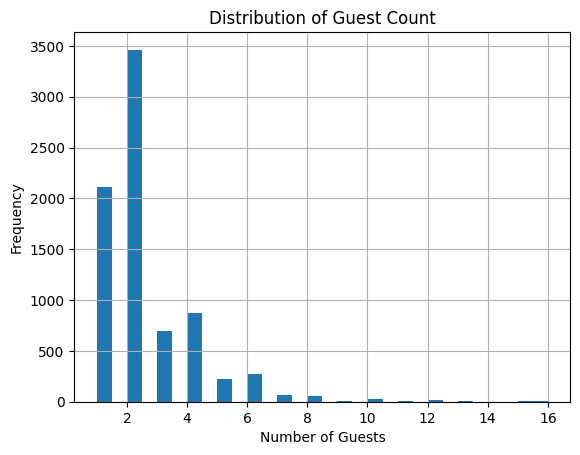

In [220]:
guest_hist = result['n_guests'].hist(bins=30)
guest_hist.set_title('Distribution of Guest Count')
guest_hist.set_ylabel('Frequency')
guest_hist.set_xlabel('Number of Guests')

#### Length-of-Stay Distribution

The number of nights is strongly right-skewed. Most stays are short, while long stays occur much less frequently and appear as a small number of extreme observations.

Text(0.5, 0, 'Number of Nights')

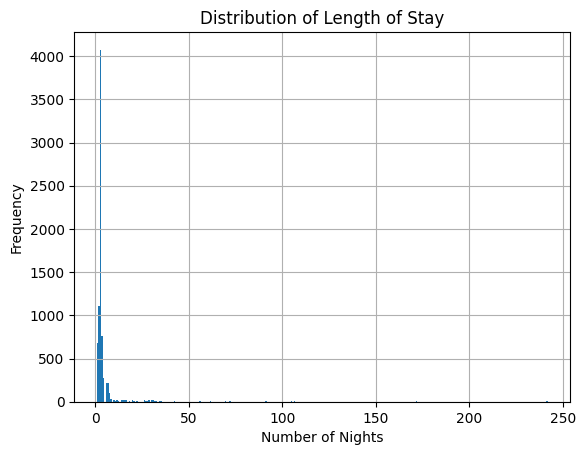

In [221]:
nights_hist = result['n_nights'].hist(bins=300)
nights_hist.set_title('Distribution of Length of Stay')
nights_hist.set_ylabel('Frequency')
nights_hist.set_xlabel('Number of Nights')

#### Room Type Distribution

The number of guests who preferred entire home or apartment are the highest among all the different preferences across different guests.

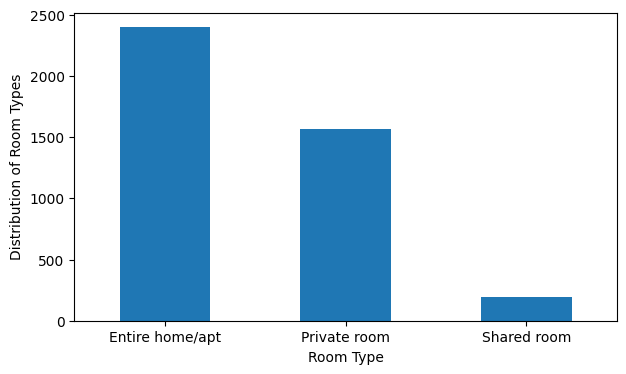

In [222]:
room_type_bar = result[['Entire home/apt', 'Private room', 'Shared room']].sum()
room_type_bar = room_type_bar.plot(kind='bar', figsize=(7,4))
room_type_bar.set_xlabel('Room Type')
room_type_bar.set_ylabel('Distribution of Room Types')
room_type_bar.tick_params(axis='x', labelrotation=0)

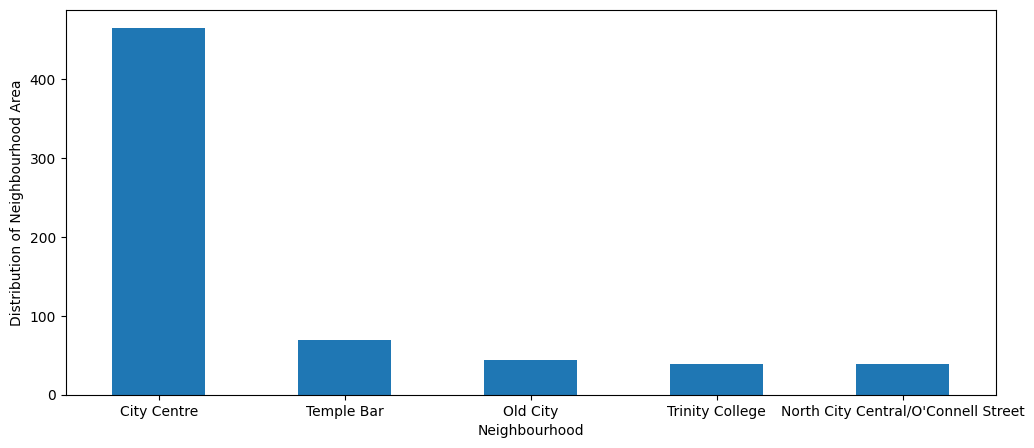

In [223]:
top_neigh = result[['Ardilea', 'Ballsbridge', 'City Centre', 'Clontarf', 'Courtlands', 'Docklands', 'Donnybrook', 'Drumcondra', 'East Wall',
       'Edenmore', 'Fairview', 'Finglas', 'Glasnevin', 'Grafton Street/St. Stephens Green', "North City Central/O'Connell Street", 'North Strand', 'Old City', 'Phibsborough', 'Portobello', 'Ranelagh and Rathmines', 'Rathfarnham',
       'Ringsend/Irishtown', 'Smithfield', 'Stoneybatter/Arbour Hill', 'Temple Bar', 'Trinity College']].sum()
top_neigh = top_neigh.sort_values(ascending=False).head(5)
top_neigh = top_neigh.plot(kind='bar', figsize=(12,5))
top_neigh.set_xlabel('Neighbourhood')
top_neigh.set_ylabel('Distribution of Neighbourhood Area')
top_neigh.tick_params(axis='x', labelrotation=0)

#### Predictive Modeling

This section tests whether neighbourhood, room type, stay length, and guest-related features can explain demand and price-filter behaviour.

#### Experiment 1: Predicting Minimum Price Filter

An XGBoost model is first used to estimate the minimum price filter selected by users based on neighbourhood, property type, number of guests, and stay length.

In [224]:
X = result[['n_nights', 'n_guests', 'Entire home/apt', 'Private room', 'Shared room', 'Ardilea', 'Ballsbridge', 'City Centre', 'Clontarf', 'Courtlands', 'Docklands', 'Donnybrook', 'Drumcondra', 'East Wall',
       'Edenmore', 'Fairview', 'Finglas', 'Glasnevin', 'Grafton Street/St. Stephens Green', "North City Central/O'Connell Street", 'North Strand', 'Old City', 'Phibsborough', 'Portobello', 'Ranelagh and Rathmines', 'Rathfarnham',
       'Ringsend/Irishtown', 'Smithfield', 'Stoneybatter/Arbour Hill', 'Temple Bar', 'Trinity College']]

In [225]:
y_min = result['filter_price_min']
y_min_mean = result['filter_price_min'].mean().round(2)
y_min = y_min.fillna(y_min_mean)
y_min = y_min.replace(0.00, y_min_mean)

In [226]:
X_train, X_val, y_train, y_val = train_test_split(X, y_min, test_size=0.2, random_state=42)

model_ = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
model_.fit(X_train, y_train)
pred = model_.predict(X_val)

In [227]:
print("Predictions:", pred[:10])
print("Actual:", y_val.iloc[:10].values)

Predictions: [ 3.7773745  -0.97245455  1.752881    4.562653    2.0534182   4.562653
  3.307205    3.7773745   3.7773745   3.3400924 ]
Actual: [2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72]


In [228]:
print("MAE:", round(mean_absolute_error(y_val, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_val, pred)), 2))
print("R2:", round(r2_score(y_val, pred), 2))

MAE: 4.44
RMSE: 25.11
R2: 0.16


#### Baseline Comparison for Price Filter Prediction

A simple mean baseline is used to check whether the machine learning model adds real predictive value.

In [229]:
baseline_pred_price = np.full(len(y_val), y_train.mean())

In [230]:
print("Baseline Prediction:", baseline_pred_price[:10])
print("Baseline Actual:", y_val.iloc[:10].values)

Baseline Prediction: [5.56279322 5.56279322 5.56279322 5.56279322 5.56279322 5.56279322
 5.56279322 5.56279322 5.56279322 5.56279322]
Baseline Actual: [2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72 2.72]


In [231]:
print("Baseline MAE:", round(mean_absolute_error(y_val, baseline_pred_price), 2))
print("Baseline RMSE:", round(np.sqrt(mean_squared_error(y_val, baseline_pred_price)), 2))
print("Baseline R2 Score:", round(r2_score(y_val, baseline_pred_price), 2))

Baseline MAE: 4.79
Baseline RMSE: 27.39
Baseline R2 Score: -0.0


**Conclusion:** The price-filter model performs poorly. Its errors are large and the negative $R^2$ indicates that it does worse than a simple mean-based baseline.

#### Experiment 2: Predicting Guest Count

After assessing the available variables, n_guests was selected as the final regression target because the available price filter variables were noisy and unreliable. Guest count is a stronger proxy for demand in this dataset, the next model focuses on predicting the number of guests from stay and location features.

In [232]:
X = result[['n_nights', 'Entire home/apt', 'Private room', 'Shared room', 'Ardilea', 'Ballsbridge', 'City Centre', 'Clontarf', 'Courtlands', 'Docklands', 'Donnybrook', 'Drumcondra', 'East Wall',
       'Edenmore', 'Fairview', 'Finglas', 'Glasnevin', 'Grafton Street/St. Stephens Green', "North City Central/O'Connell Street", 'North Strand', 'Old City', 'Phibsborough', 'Portobello', 'Ranelagh and Rathmines', 'Rathfarnham',
       'Ringsend/Irishtown', 'Smithfield', 'Stoneybatter/Arbour Hill', 'Temple Bar', 'Trinity College']]

In [233]:
y = result['n_guests']

In [234]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_val)

In [235]:
print("Predictions:", pred[:10].round(2))
print("Actual:", y_val.iloc[:10].values)

Predictions: [2.44 2.68 1.55 2.44 3.01 2.44 2.02 2.44 2.44 3.22]
Actual: [2 2 1 4 2 4 2 2 2 4]


In [236]:
print("MAE:", round(mean_absolute_error(y_val, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_val, pred)), 2))
print("R2:", round(r2_score(y_val, pred), 2))

MAE: 1.04
RMSE: 1.52
R2: 0.08


#### Baseline for Guest Count Prediction

The mean baseline provides a simple reference point for evaluating whether the model captures useful demand patterns.

In [237]:
baseline_pred = np.full(len(y_val), y_train.mean())

In [238]:
print("Baseline Prediction:", baseline_pred[:10].round(2))
print("Baselin Actual:", y_val.iloc[:10].values)

Baseline Prediction: [2.43 2.43 2.43 2.43 2.43 2.43 2.43 2.43 2.43 2.43]
Baselin Actual: [2 2 1 4 2 4 2 2 2 4]


In [239]:
print("Baseline MAE:", round(mean_absolute_error(y_val, baseline_pred), 2))
print("Baseline RMSE:", round(np.sqrt(mean_squared_error(y_val, baseline_pred)), 2))
print("Baseline R2:", round(r2_score(y_val, baseline_pred), 2))

Baseline MAE: 1.12
Baseline RMSE: 1.58
Baseline R2: -0.0


#### Linear Regression Benchmark

A Linear Regression model is included as a simple and interpretable benchmark alongside XGBoost and the naive baseline.

In [240]:
X_train_lr = X_train.fillna(0)
X_val_lr = X_val.fillna(0)
y_train_lr = y_train.fillna(0)
y_val_lr = y_val.fillna(0)

In [241]:
lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)
lr_pred = lr.predict(X_val_lr)

In [242]:
print("Predictions:", lr_pred[:10].round(2))
print("Actual:", y_val.iloc[:10].values)

Predictions: [2.42 3.2  1.49 2.42 3.14 2.42 2.43 2.42 2.42 3.09]
Actual: [2 2 1 4 2 4 2 2 2 4]


In [243]:
print("Linear Regression MAE:", round(mean_absolute_error(y_val_lr, lr_pred), 2))
print("Linear Regression RMSE:", round(np.sqrt(mean_squared_error(y_val_lr, lr_pred)), 2))
print("R2 Score:", round(r2_score(y_val_lr, lr_pred), 2))

Linear Regression MAE: 1.06
Linear Regression RMSE: 1.53
R2 Score: 0.06


#### Model Comparison

In [244]:
final_result = pd.DataFrame({
    "Model": ["Mean Baseline", "Linear Regression", "XGBoost"],
    "MAE": [round(mean_absolute_error(y_val, baseline_pred), 2), round(mean_absolute_error(y_val_lr, lr_pred), 2), round(mean_absolute_error(y_val, pred), 2)],
    "RMSE": [round(np.sqrt(mean_squared_error(y_val, baseline_pred)), 2), round(np.sqrt(mean_squared_error(y_val_lr, lr_pred)), 2), round(np.sqrt(mean_squared_error(y_val, pred)), 2)],
    "R2 Score": [round(r2_score(y_val, baseline_pred), 2), round(r2_score(y_val_lr, lr_pred), 2), round(r2_score(y_val, pred), 2)]
})

In [245]:
final_result

,Model,MAE,RMSE,R2 Score
0,Mean Baseline,1.12,1.58,-0.00
1,Linear Regression,1.06,1.53,0.06
2,XGBoost,1.04,1.52,0.08


**Conclusion:** XGBoost performs slightly better than both the mean baseline and Linear Regression when predicting guest count. However, the low $R^2$ shows that the model still explains only a small share of demand variation, so the predictive power remains limited.

#### Feature Importance for the XGBoost Model

In [246]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Private room                           0.350156
Entire home/apt                        0.241278
n_nights                               0.066725
Temple Bar                             0.052864
Ballsbridge                            0.032323
Trinity College                        0.029442
City Centre                            0.024964
North City Central/O'Connell Street    0.024371
Shared room                            0.024165
Old City                               0.022283
dtype: float32

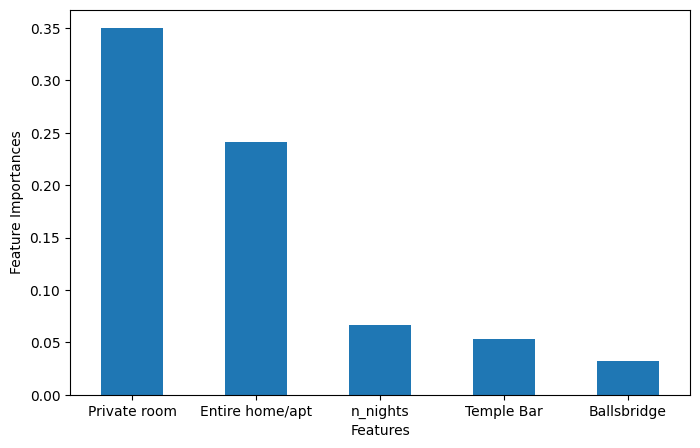

In [255]:
importance_bar = importance.sort_values(ascending=False).head(5)
importance_bar = importance_bar.plot(kind='bar', figsize=(8,5))
importance_bar.set_ylabel('Feature Importances')
importance_bar.set_xlabel('Features')
importance_bar.tick_params(axis='x', labelrotation=0)

Room type variables such as entire home/apartment and private room are among the strongest predictors, followed by `n_nights`. Central neighbourhoods such as Temple Bar and City Centre also appear important, highlighting the combined role of accommodation type and location.

#### Error Analysis

In [247]:
comparison = X_val.copy()
comparison['actual'] = y_val.values
comparison['pred'] = pred
comparison['abs_error'] = abs(comparison['actual'] - comparison['pred'])
comparison.sort_values("abs_error", ascending=False).head(10)

,n_nights,Entire home/apt,Private room,Shared room,Ardilea,Ballsbridge,City Centre,Clontarf,Courtlands,Docklands,...,Ranelagh and Rathmines,Rathfarnham,Ringsend/Irishtown,Smithfield,Stoneybatter/Arbour Hill,Temple Bar,Trinity College,actual,pred,abs_error
17902,3.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,16,2.439153,13.560847
1680,8.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,16,3.260753,12.739247
22794,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,2.473481,9.526519
10872,3.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,11,2.439153,8.560847
17259,3.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,2.439153,7.560847
26428,3.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,2.439153,7.560847
22795,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,2.473481,7.526519
22793,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,2.473481,7.526519
18928,2.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,2.473481,7.526519
21208,5.0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,3.260659,6.739341


In [248]:
comparison[['actual', 'pred', 'abs_error']].sort_values("abs_error", ascending=False).head(10)

,actual,pred,abs_error
17902,16,2.439153,13.560847
1680,16,3.260753,12.739247
22794,12,2.473481,9.526519
10872,11,2.439153,8.560847
17259,10,2.439153,7.560847
26428,10,2.439153,7.560847
22795,10,2.473481,7.526519
22793,10,2.473481,7.526519
18928,10,2.473481,7.526519
21208,10,3.260659,6.739341


The largest errors occur for very high actual guest counts. In those cases, the model predicts values closer to 2 to 3 guests while the true counts are much higher, suggesting that the dataset is dominated by smaller groups and the model underpredicts rare large bookings.

#### Final Takeaways

- Guest count was used as a demand proxy because the dataset did not contain confirmed bookings, occupancy, revenue, or a clean nightly listing price field
- XGBoost outperformed Linear Regression and the naive mean baseline, showing that the available features contained some predictive signal. 
- However, the low R2 score suggests that guest count variation is only weakly explained by the current features.
- This project should be interpreted as demand proxy modeling rather than true demand forecasting.
- The main value of the project is in data cleaning, feature engineering, baseline comparison, model benchmarking, and understanding the limitations of imperfect marketplace data.
- Future improvements could include confirmed bookings, occupancy rate, nightly price, seasonality, event dates, review history and host-level features.